In [201]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [202]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

In [203]:
data_set = df.copy()
y = data_set['target_class']
X = data_set.drop(columns=["target_class"])

# Logistic Regression

In [214]:

#Hold out method
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(
    multi_class='ovr',  # one-vs-rest
    solver='liblinear', # liblinear works well for OvR
    max_iter=5000
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Fit the model
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

    class_45       0.72      0.76      0.74       217
    class_65       0.98      0.99      0.99       197
    class_73       0.70      0.64      0.67       186

    accuracy                           0.80       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.80      0.80      0.80       600



# LDA

In [205]:
lda = LDA()
lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)

print("\nLDA Classification Report:\n", classification_report(y_test, y_pred_lda))



LDA Classification Report:
               precision    recall  f1-score   support

    class_45       0.65      0.68      0.66       217
    class_65       0.94      0.92      0.93       197
    class_73       0.63      0.61      0.62       186

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600



# QDA

In [206]:

# Define a range of regularization values to test
reg_params = np.linspace(0.1, 1, 11)  # e.g., 0.0, 0.05, 0.1, ..., 0.5

results = []

for reg in reg_params:
    qda = QDA(reg_param=reg)
    qda.fit(X_train_scaled, y_train)
    y_pred_qda = qda.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_qda)
    f1 = f1_score(y_test, y_pred_qda, average="macro")

    results.append({
        "reg_param": reg,
        "accuracy": acc,
        "macro_f1": f1
    })
# Convert results to DataFrame for analysis
results_df = pd.DataFrame(results)



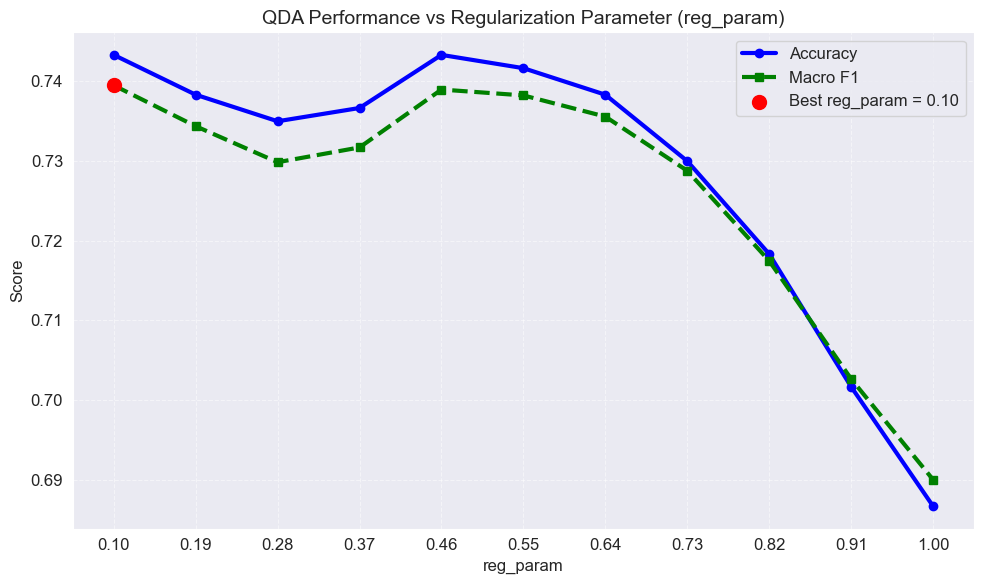

In [207]:
# Assume results_df from the previous loop exists
plt.figure(figsize=(10, 6))

# Plot Accuracy
plt.plot(results_df["reg_param"], results_df["accuracy"], marker='o', linestyle='-', color='blue', label="Accuracy")

# Plot Macro F1
plt.plot(results_df["reg_param"], results_df["macro_f1"], marker='s', linestyle='--', color='green', label="Macro F1")

# Highlight the best reg_param (highest Macro F1)
best_idx = results_df["macro_f1"].idxmax()
best_reg = results_df.loc[best_idx, "reg_param"]
best_f1 = results_df.loc[best_idx, "macro_f1"]
plt.scatter(best_reg, best_f1, color='red', s=100, zorder=5, label=f"Best reg_param = {best_reg:.2f}")

# Labels and formatting
plt.title("QDA Performance vs Regularization Parameter (reg_param)", fontsize=14)
plt.xlabel("reg_param", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(results_df["reg_param"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [208]:
qda_best = QDA(reg_param=best_reg)
qda_best.fit(X_train_scaled, y_train)
y_pred_best = qda_best.predict(X_test_scaled)

print("\nFinal QDA Classification Report (Best reg_param):")
print(classification_report(y_test, y_pred_best))


Final QDA Classification Report (Best reg_param):
              precision    recall  f1-score   support

    class_45       0.64      0.80      0.71       217
    class_65       0.96      0.90      0.93       197
    class_73       0.67      0.52      0.58       186

    accuracy                           0.74       600
   macro avg       0.75      0.74      0.74       600
weighted avg       0.75      0.74      0.74       600



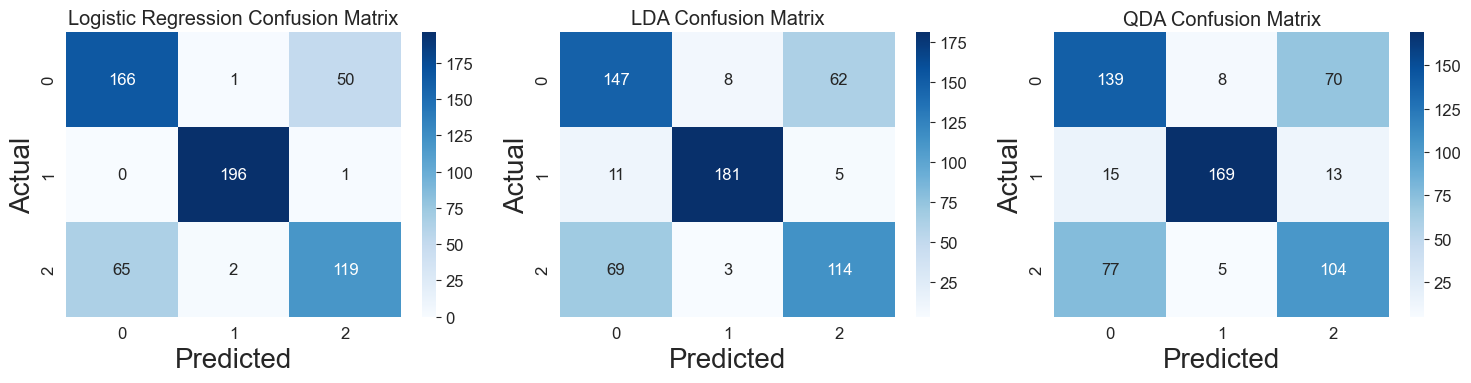

In [209]:
models = {
    "Logistic Regression": y_pred,
    "LDA": y_pred_lda,
    "QDA": y_pred_qda
}

plt.figure(figsize=(15, 4))
for i, (name, preds) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

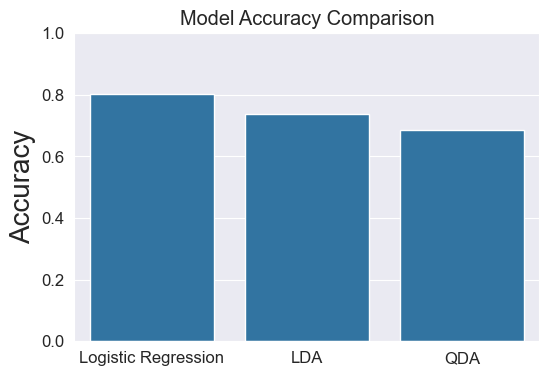

In [210]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "LDA": accuracy_score(y_test, y_pred_lda),
    "QDA": accuracy_score(y_test, y_pred_qda)
}

plt.figure(figsize=(6, 4))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()